In [12]:
import numpy as np
from functions import clean_data, split_data
from NN_functions import initialize_parameters, relu, softplus, relu_derivative, softplus_derivative, feed_forward, backward_propagation
from NN_functions import init_adam_state, adam_update, train_model, predict, tune_nn, train_final_model
from NN_functions import get_output_derivative
import matplotlib.pyplot as plt

In [2]:
X, Y = clean_data("claims_train.csv")
X_train, X_val, y_train, y_val = split_data(X, Y, 0.2)
X_test, y_test = clean_data("claims_test.csv")
y_train = y_train.to_numpy()

In [4]:
output_functions = {
    "softplus": (softplus, softplus_derivative),
    "relu": (relu, relu_derivative)
}

batch_sizes = [16, 32, 64, 128, 256, 512]

best_batch_size, best_out_func, best_avg_loss, best_epoch = tune_nn(
    X_train, y_train,
    batch_sizes=batch_sizes,
    output_functions=output_functions,
    learning_rate=0.001,
    epochs=150,
    k=3
)

Early stopping at epoch 16
Early stopping at epoch 22
Early stopping at epoch 15
batch=16, out=softplus -> avg MSE: 0.055979, avg Poisson: 0.200047
Early stopping at epoch 5
Early stopping at epoch 5
Early stopping at epoch 5
batch=16, out=relu -> avg MSE: 0.060187, avg Poisson: 0.985076
Early stopping at epoch 14
Early stopping at epoch 24
Early stopping at epoch 18
batch=32, out=softplus -> avg MSE: 0.055982, avg Poisson: 0.200159
Early stopping at epoch 5
Early stopping at epoch 5
Early stopping at epoch 5
batch=32, out=relu -> avg MSE: 0.060187, avg Poisson: 0.985076
Early stopping at epoch 14
Early stopping at epoch 24
Early stopping at epoch 23
batch=64, out=softplus -> avg MSE: 0.055980, avg Poisson: 0.200217
Early stopping at epoch 5
Early stopping at epoch 5
Early stopping at epoch 6
batch=64, out=relu -> avg MSE: 0.060909, avg Poisson: 0.976027
Early stopping at epoch 27
Early stopping at epoch 25
Early stopping at epoch 18
batch=128, out=softplus -> avg MSE: 0.056153, avg Po

In [3]:
best_batch_size = 16
best_out_func = softplus
best_epoch = 17

In [4]:

final_params = train_final_model(
    X_train, y_train,
    learning_rate=0.001,
    batch_size= best_batch_size,
    epochs=best_epoch,
    output_function=best_out_func,
    output_func_der=get_output_derivative(best_out_func)
)

In [9]:
y_train_pred = predict(X_train, final_params, best_out_func)
train_mse = np.mean((y_train.reshape(-1,1) - y_train_pred)**2)
print("Train MSE:", train_mse)

y_val_pred = predict(X_val, final_params, best_out_func)
val_mse = np.mean((y_val.to_numpy().reshape(-1,1) - y_val_pred)**2)
print("Validation MSE:", val_mse)

y_test_pred = predict(X_test, final_params, best_out_func)
test_mse = np.mean((y_test.to_numpy().reshape(-1,1) - y_test_pred)**2)
print("TEST MSE (final):", test_mse)

Train MSE: 0.05559041573756194
Validation MSE: 0.05460519969024643
TEST MSE (final): 0.05884923981077861


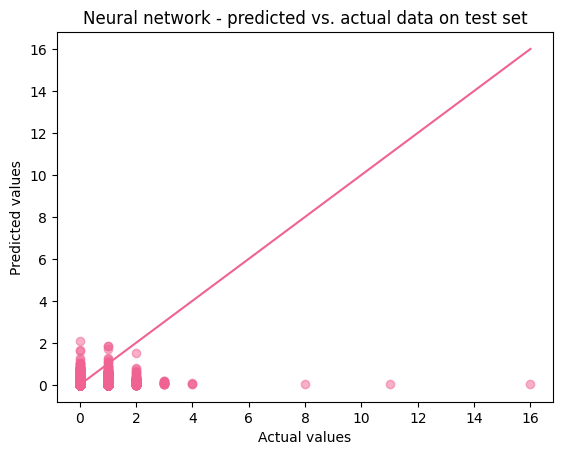

In [14]:
plt.figure()
plt.scatter(y_test, y_test_pred, alpha=0.5, color='#F06292')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], color='#F06292')
plt.xlabel("Actual values")
plt.ylabel("Predicted values")
plt.title("Neural network - predicted vs. actual data on test set")

plt.savefig("Neural Network - predicted vs. actual on test data.png", dpi=300, bbox_inches='tight')

plt.show()

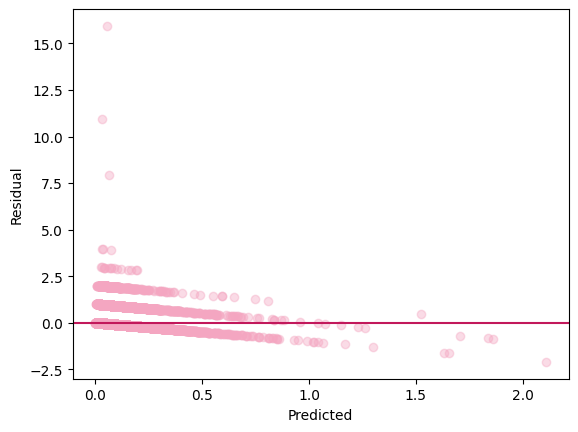

In [20]:
residuals = y_test.to_numpy().reshape(-1,1) - y_test_pred
plt.scatter(y_test_pred, residuals, color = "#f4a6c1", alpha=0.4)
plt.axhline(0, color="#c2185b")
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.savefig("Neural Network - residual plot on test", dpi=300, bbox_inches='tight')

plt.show()